# Part 1, Task 3 - develop A* Search Algorithm with a suitable heuristic function.

For this task, we decided to use Euclidean distance as our heuristic function. This serves as an approximation for the algorithm to calculate the distance between the current node and the goal node.

we shall use f(n) = a * g(n) + b* h(n), 
where g(n) is the culmulative cost from the start node to the current node, and h(n) is the heuristic cost estimate from the current node to the goal node.

Considerations: 
1. Our goal is to find the shortest distance from the start node to the goal node, this does not mean the least number of nodes. 
2. Energy cost does not matter as long as it does not exceed the limit of 287932.

In [ ]:
import json
import heapq
import time
import matplotlib.pyplot as plt

with open("../data/G.json", "r") as f:
    G = json.load(f)

with open("../data/Coord.json", "r") as f:
    Coord = json.load(f)

with open("../data/Dist.json", "r") as f:
    Dist = json.load(f)

with open("../data/Cost.json", "r") as f:
    Cost = json.load(f)

with open("../data/heuristic.json", "r") as f:
    heuristic = json.load(f)


def a_star_distance(G, Cost, Dist, heuristic, start, goal, max_energy, alpha=1, beta=1):
    """
    Weighted A* search:
        f(n) = alpha * g(n) + beta * h(n)

    Goal:
        Find shortest distance path while staying within energy constraint.
    """

    # (f(n), node, path, energy_used, distance_travelled)
    pq = [(0, start, [start], 0, 0)]

    visited = dict()
    nodes_expanded = 0
    explored_nodes = []  # store explored order

    while pq:
        f_n, node, path, energy_used, dist_travelled = heapq.heappop(pq)

        nodes_expanded += 1
        explored_nodes.append(node)

        # Skip if energy exceeded
        if energy_used > max_energy:
            continue

        # Goal check
        if node == goal:
            return path, dist_travelled, energy_used, nodes_expanded, explored_nodes

        # Skip if visited with smaller distance
        if node in visited and visited[node] <= dist_travelled:
            continue

        visited[node] = dist_travelled

        # Explore neighbors
        for neighbor in G.get(node, []):
            edge_key = f"{node},{neighbor}"

            edge_cost = Cost.get(edge_key)
            edge_dist = Dist.get(edge_key)
            h = heuristic.get(neighbor, 0)

            new_energy = energy_used + edge_cost
            new_dist = dist_travelled + edge_dist

            f_new = alpha * new_dist + beta * h

            heapq.heappush(
                pq,
                (f_new, neighbor, path + [neighbor], new_energy, new_dist)
            )

    return None, None, None, nodes_expanded, explored_nodes


alpha = 1.0
beta = 1.0

start_node = "1"
goal_node = "50"
max_energy = 287932

start_time = time.time()

path, dist_travelled, energy_used, nodes_expanded, explored_nodes = a_star_distance(
    G, Cost, Dist, heuristic,
    start_node, goal_node, max_energy, alpha, beta
)

end_time = time.time()

print("A* results with fixed alpha and beta:")
print(f"Alpha: {alpha}")
print(f"Beta: {beta}")
print(f"Distance travelled: {dist_travelled:.2f}")
print(f"Energy used: {energy_used:.2f}")
print(f"Nodes expanded: {nodes_expanded}")
print(f"Execution time: {end_time - start_time:.4f} seconds")

print("\nFinal path:")
print(path)

print("\nNodes explored in order:")
print(explored_nodes)

A* results with fixed alpha and beta:
Alpha: 1.0
Beta: 1.0
Distance travelled: 150784.61
Energy used: 287931.00
Nodes expanded: 3530
Execution time: 0.0072 seconds

Final path:
['1', '1363', '1358', '1357', '1356', '1276', '1273', '1277', '1269', '1267', '1268', '1284', '1283', '1282', '1255', '1253', '1260', '1259', '1249', '1246', '963', '964', '962', '1002', '952', '1000', '998', '994', '995', '996', '987', '986', '979', '980', '969', '977', '989', '990', '991', '2369', '2366', '2340', '2338', '2339', '2333', '2334', '2329', '2029', '2027', '2019', '2022', '2000', '1996', '1997', '1993', '1992', '1989', '1984', '2001', '1900', '1875', '1874', '1965', '1963', '1964', '1923', '1944', '1945', '1938', '1937', '1939', '1935', '1931', '1934', '1673', '1675', '1674', '1837', '1671', '1828', '1825', '1817', '1815', '1634', '1814', '1813', '1632', '1631', '1742', '1741', '1740', '1739', '1591', '1689', '1585', '1584', '1688', '1579', '1679', '1677', '104', '5680', '5418', '5431', '5425', '54

In [6]:
import heapq
import time

def a_star_distance(G, Cost, Dist, heuristic, start, goal, max_energy, alpha=1, beta=1):
    """
    A* search with energy constraint.
    f(n) = alpha * g(n) + beta * h(n)

    g(n) = distance travelled so far
    h(n) = heuristic estimate to goal
    """

    pq = []
    heapq.heappush(pq, (0, start))

    # Best known distance from start
    g_score = {node: float('inf') for node in G}
    g_score[start] = 0

    # Track energy usage
    energy_used = {node: float('inf') for node in G}
    energy_used[start] = 0

    # Parent pointers (for path reconstruction)
    prev = {node: None for node in G}

    nodes_expanded = 0
    explored_nodes = []  # <--- track order of nodes explored

    while pq:
        f_n, node = heapq.heappop(pq)
        nodes_expanded += 1
        explored_nodes.append(node)  # <--- add node to explored list

        if node == goal:
            break

        for neighbor in G.get(node, []):

            edge_key = f"{node},{neighbor}"

            edge_dist = Dist[edge_key]
            edge_cost = Cost[edge_key]

            tentative_g = g_score[node] + edge_dist
            tentative_energy = energy_used[node] + edge_cost

            # Skip if energy constraint violated
            if tentative_energy > max_energy:
                continue

            # Proper A* pruning
            if tentative_g < g_score[neighbor]:

                prev[neighbor] = node
                g_score[neighbor] = tentative_g
                energy_used[neighbor] = tentative_energy

                h = heuristic.get(neighbor, 0)

                f_new = alpha * tentative_g + beta * h

                heapq.heappush(pq, (f_new, neighbor))

    # Reconstruct path
    path = []
    node_ptr = goal

    if prev[node_ptr] is None:
        return None, None, None, nodes_expanded, explored_nodes

    while node_ptr:
        path.append(node_ptr)
        node_ptr = prev[node_ptr]

    path.reverse()

    return path, g_score[goal], energy_used[goal], nodes_expanded, explored_nodes


# Parameters
alpha = 1.0
beta = 1.0
start_node = "1"
goal_node = "50"
max_energy = 287932

start_time = time.time()

path, dist_travelled, energy_used, nodes_expanded, explored_nodes = a_star_distance(
    G, Cost, Dist, heuristic,
    start_node, goal_node, max_energy, alpha, beta
)

end_time = time.time()

print("A* results with fixed alpha and beta:")
print(f"Alpha: {alpha}")
print(f"Beta: {beta}")
print(f"Distance travelled: {dist_travelled:.2f}")
print(f"Energy used: {energy_used:.2f}")
print(f"Nodes expanded: {nodes_expanded}")
print(f"Execution time: {end_time - start_time:.4f} seconds")

print("\nFinal path:")
print(path)
print("\nlength of path:", len(path))




A* results with fixed alpha and beta:
Alpha: 1.0
Beta: 1.0
Distance travelled: 150784.61
Energy used: 287931.00
Nodes expanded: 1753
Execution time: 0.2143 seconds

Final path:
['1', '1363', '1358', '1357', '1356', '1276', '1273', '1277', '1269', '1267', '1268', '1284', '1283', '1282', '1255', '1253', '1260', '1259', '1249', '1246', '963', '964', '962', '1002', '952', '1000', '998', '994', '995', '996', '987', '988', '979', '980', '969', '977', '989', '990', '991', '2369', '2366', '2340', '2338', '2339', '2333', '2334', '2329', '2029', '2027', '2019', '2022', '2000', '1996', '1997', '1993', '1992', '1989', '1984', '2001', '1900', '1875', '1874', '1965', '1963', '1964', '1923', '1944', '1945', '1938', '1937', '1939', '1935', '1931', '1934', '1673', '1675', '1674', '1837', '1671', '1828', '1825', '1817', '1815', '1634', '1814', '1813', '1632', '1631', '1742', '1741', '1740', '1739', '1591', '1689', '1585', '1584', '1688', '1579', '1679', '1677', '104', '5680', '5418', '5431', '5425', '54

# Determining appropriate alpha and beta values for f(n) = a * g(n) + b* h(n)

To determine appropriate alpha and beta values, we approximate them through trial and error. We start with alpha = 0.5 and beta = 0.5, and adjust them based on the performance of the algorithm.

In [ ]:
import json
import heapq
import math
import time
import matplotlib.pyplot as plt

with open("../data/G.json", "r") as f:
    G = json.load(f)       
with open("../data/Coord.json", "r") as f:
    Coord = json.load(f)    
with open("../data/Dist.json", "r") as f:
    Dist = json.load(f)     
with open("../data/Cost.json", "r") as f:
    Cost = json.load(f)    
with open("../data/heuristic.json", "r") as f:
    heuristic = json.load(f) 
    
def a_star_distance(G, Cost, Dist, heuristic, start, goal, max_energy, alpha=1, beta=1):
    """
    Weighted A* search:
        f(n) = alpha*g(n) + beta*h(n)
        Energy is tracked separately as constraint.
        Goal: shortest distance path within energy limit.
    """
    pq = [(0, start, [start], 0, 0)]  # (f(n), node, path, energy_used, distance_travelled)
    visited = dict()  # track lowest distance to node
    nodes_expanded = 0

    while pq:
        f_n, node, path, energy_used, dist_travelled = heapq.heappop(pq)
        nodes_expanded += 1

        # Skip if energy exceeded
        if energy_used > max_energy:
            continue

        # Goal check
        if node == goal:
            return path, dist_travelled, energy_used, nodes_expanded

        # Skip if visited with smaller distance
        if node in visited and visited[node] <= dist_travelled:
            continue
        visited[node] = dist_travelled

        # Explore neighbors
        for neighbor in G.get(node, []):
            edge_key = f"{node},{neighbor}"
            edge_cost = Cost.get(edge_key, float('inf'))         # energy
            edge_dist = Dist.get(edge_key, float('inf'))         # actual distance
            h = heuristic.get(neighbor, 0)

            new_energy = energy_used + edge_cost
            new_dist = dist_travelled + edge_dist
            f_new = alpha * new_dist + beta * h  # Only raw distance and heuristic, no normalization

            heapq.heappush(pq, (f_new, neighbor, path + [neighbor], new_energy, new_dist))

    return None, None, None, nodes_expanded

def frange(start, stop, step):
    while start <= stop:
        yield start
        start += step



Best combination of alpha and beta:
Alpha: 10
Beta: 0
Distance travelled: 150784.61
Energy used: 287931.00
Nodes expanded: 12458


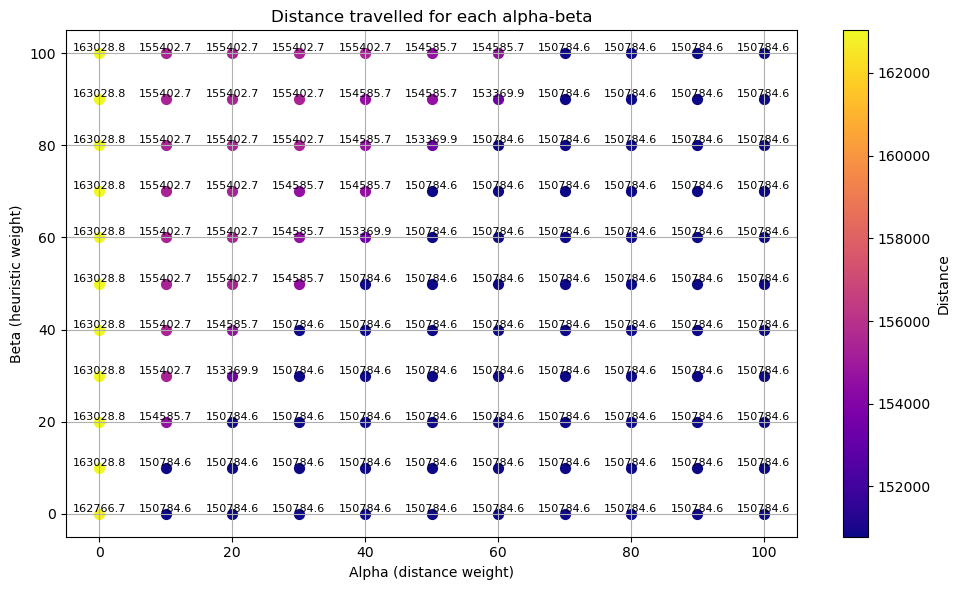

In [ ]:
start_node = "1"
goal_node = "50"
max_energy = 287932

alpha_start = 0
alpha_end = 100
alpha_step = 5

beta_start = 0
beta_end = 100
beta_step = 5

alpha_values = [round(a,2) for a in frange(alpha_start, alpha_end, alpha_step)]
beta_values = [round(b,2) for b in frange(beta_start, beta_end, beta_step)]

results = []

for alpha in alpha_values:
    for beta in beta_values:
        path, dist_travelled, energy_used, nodes_expanded = a_star_distance(
            G, Cost, Dist, heuristic,
            start_node, goal_node, max_energy, alpha, beta
        )

        results.append({
            "alpha": alpha,
            "beta": beta,
            "distance_travelled": dist_travelled,
            "energy_used": energy_used,
            "nodes_expanded": nodes_expanded
        })

# Track the best combination
best_result = None

# Iterate through the results and find the best combination
for r in results:
    if best_result is None:
        best_result = r
    else:
        if r["distance_travelled"] < best_result["distance_travelled"]:
            best_result = r

# Print the best result
if best_result:
    print("Best combination of alpha and beta:")
    print(f"Alpha: {best_result['alpha']}")
    print(f"Beta: {best_result['beta']}")
    print(f"Distance travelled: {best_result['distance_travelled']:.2f}")
    print(f"Energy used: {best_result['energy_used']:.2f}")
    print(f"Nodes expanded: {best_result['nodes_expanded']}")


# Distance travelled vs Alpha-Beta
plt.figure(figsize=(10, 6))

# Get the min and max values for distance to set the color scale
dist_min = min(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)
dist_max = max(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)

# Create a scatter plot for Distance travelled vs Alpha-Beta
for r in results:
    if r["distance_travelled"] is not None:
        plt.scatter(r["alpha"], r["beta"], s=50, c=r["distance_travelled"], cmap="plasma", vmin=dist_min, vmax=dist_max)
        plt.text(r["alpha"], r["beta"], f"{r['distance_travelled']:.1f}", fontsize=8, ha='center', va='bottom')

plt.xlabel("Alpha (distance weight)")
plt.ylabel("Beta (heuristic weight)")
plt.title("Distance travelled for each alpha-beta")
plt.colorbar(label="Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

Best combination of alpha and beta:
Alpha: 0.5
Beta: 0
Distance travelled: 150784.61
Energy used: 287931.00
Nodes expanded: 12458


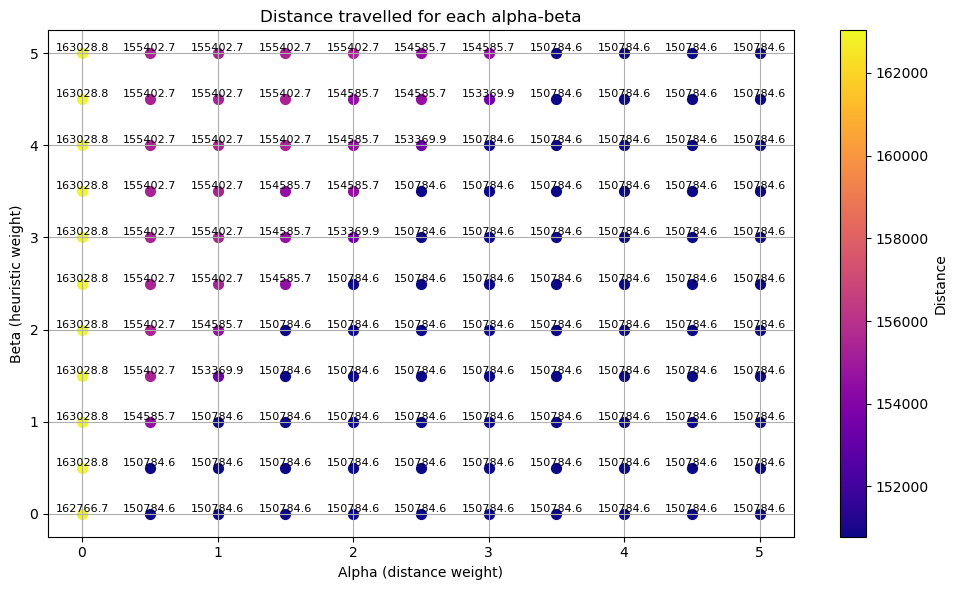

In [48]:
start_node = "1"
goal_node = "50"
max_energy = 287932

alpha_start = 0
alpha_end = 5
alpha_step = 0.5

beta_start = 0
beta_end = 5
beta_step = 0.5

alpha_values = [round(a,2) for a in frange(alpha_start, alpha_end, alpha_step)]
beta_values = [round(b,2) for b in frange(beta_start, beta_end, beta_step)]

results = []

for alpha in alpha_values:
    for beta in beta_values:
        path, dist_travelled, energy_used, nodes_expanded = a_star_distance(
            G, Cost, Dist, heuristic,
            start_node, goal_node, max_energy, alpha, beta
        )

        results.append({
            "alpha": alpha,
            "beta": beta,
            "distance_travelled": dist_travelled,
            "energy_used": energy_used,
            "nodes_expanded": nodes_expanded
        })

# Track the best combination
best_result = None

# Iterate through the results and find the best combination
for r in results:
    if best_result is None:
        best_result = r
    else:
        if r["distance_travelled"] < best_result["distance_travelled"]:
            best_result = r

# Print the best result
if best_result:
    print("Best combination of alpha and beta:")
    print(f"Alpha: {best_result['alpha']}")
    print(f"Beta: {best_result['beta']}")
    print(f"Distance travelled: {best_result['distance_travelled']:.2f}")
    print(f"Energy used: {best_result['energy_used']:.2f}")
    print(f"Nodes expanded: {best_result['nodes_expanded']}")


# Distance travelled vs Alpha-Beta
plt.figure(figsize=(10, 6))

# Get the min and max values for distance to set the color scale
dist_min = min(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)
dist_max = max(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)

# Create a scatter plot for Distance travelled vs Alpha-Beta
for r in results:
    if r["distance_travelled"] is not None:
        plt.scatter(r["alpha"], r["beta"], s=50, c=r["distance_travelled"], cmap="plasma", vmin=dist_min, vmax=dist_max)
        plt.text(r["alpha"], r["beta"], f"{r['distance_travelled']:.1f}", fontsize=8, ha='center', va='bottom')

plt.xlabel("Alpha (distance weight)")
plt.ylabel("Beta (heuristic weight)")
plt.title("Distance travelled for each alpha-beta")
plt.colorbar(label="Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

Observations from this comparison, there is no improvement in the distance calculation besides the default 150784.6 obtained from the initial a = 1, b = 1. We shall retain this as the default values for a and b respectively to prevent bias in other navigation using the A* algorithm.